In [12]:
import pandas as pd

data = pd.read_csv("../data/processed/patient_state_clean.csv")

print("Shape:", data.shape)
data.head()


Shape: (2899, 12)


,SEQN,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Glucose,HbA1c,Insulin,Total_Cholesterol,HDL_Cholesterol,Metabolic_Risk
0,93708.0,66.0,1.0,23.7,141.000000,77.000000,122.0,6.2,9.72,209.0,88.0,1
1,93711.0,56.0,0.0,21.3,101.333333,66.666667,107.0,5.7,5.28,238.0,72.0,1
2,93717.0,22.0,0.0,24.5,118.666667,65.333333,91.0,5.1,3.94,213.0,53.0,0
3,93718.0,45.0,0.0,22.0,131.333333,90.000000,89.0,5.7,4.89,152.0,63.0,1
4,93719.0,13.0,1.0,26.0,101.333333,64.000000,86.0,5.0,10.94,97.0,46.0,0


In [13]:
data = data.drop(columns=["HbA1c"])

In [14]:
FEATURES = [
    "Age", "Gender", "BMI",
    "Systolic_BP", "Diastolic_BP",
    "Glucose", "Insulin",
    "Total_Cholesterol", "HDL_Cholesterol"
]

X = data[FEATURES]
y = data["Metabolic_Risk"]


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define model
log_reg = LogisticRegression(max_iter=5000, solver='liblinear')

# Define parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='f1',   # medically better than accuracy
    n_jobs=-1
)

# Fit model
grid_search.fit(X_train_scaled, y_train)

# Best model
best_log_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)


Best Parameters: {'C': 0.01, 'penalty': 'l1'}


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_pred = best_log_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Optimized Logistic Regression Results")
print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))


Optimized Logistic Regression Results
Accuracy: 0.766
Precision: 0.711
Recall: 0.705
F1 Score: 0.708


In [19]:
import numpy as np

# Get predicted probabilities
y_prob = best_log_model.predict_proba(X_test_scaled)[:, 1]

# Adjust threshold
threshold = 0.4
y_pred_adjusted = (y_prob >= threshold).astype(int)

accuracy_adj = accuracy_score(y_test, y_pred_adjusted)
precision_adj = precision_score(y_test, y_pred_adjusted)
recall_adj = recall_score(y_test, y_pred_adjusted)
f1_adj = f1_score(y_test, y_pred_adjusted)

print("Threshold Adjusted Results (Threshold = 0.4)")
print("Accuracy:", round(accuracy_adj, 3))
print("Precision:", round(precision_adj, 3))
print("Recall:", round(recall_adj, 3))
print("F1 Score:", round(f1_adj, 3))


Threshold Adjusted Results (Threshold = 0.4)
Accuracy: 0.753
Precision: 0.647
Recall: 0.855
F1 Score: 0.737


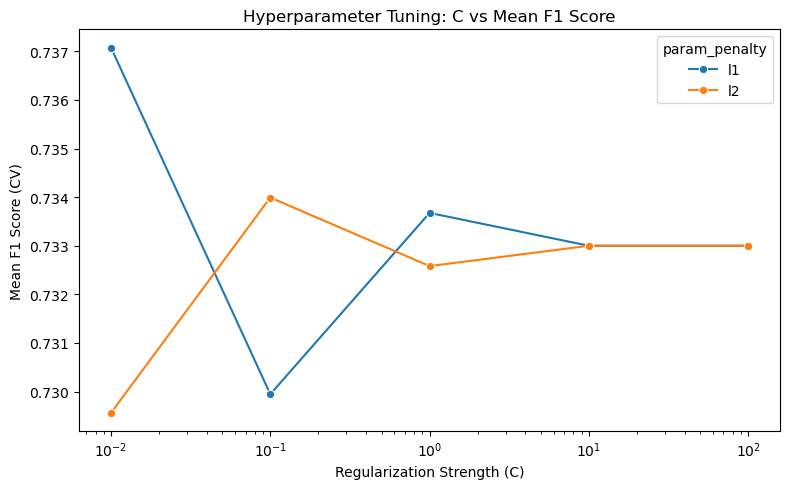

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert CV results into dataframe
cv_results = pd.DataFrame(grid_search.cv_results_)

# Extract relevant columns
results_plot = cv_results[[
    "param_C",
    "param_penalty",
    "mean_test_score"
]]

plt.figure(figsize=(8,5))
sns.lineplot(
    data=results_plot,
    x="param_C",
    y="mean_test_score",
    hue="param_penalty",
    marker="o"
)

plt.xscale("log")
plt.title("Hyperparameter Tuning: C vs Mean F1 Score")
plt.xlabel("Regularization Strength (C)")
plt.ylabel("Mean F1 Score (CV)")
plt.tight_layout()
plt.savefig("hyper_parameter_tuning_curve.png", dpi=300)
plt.show()


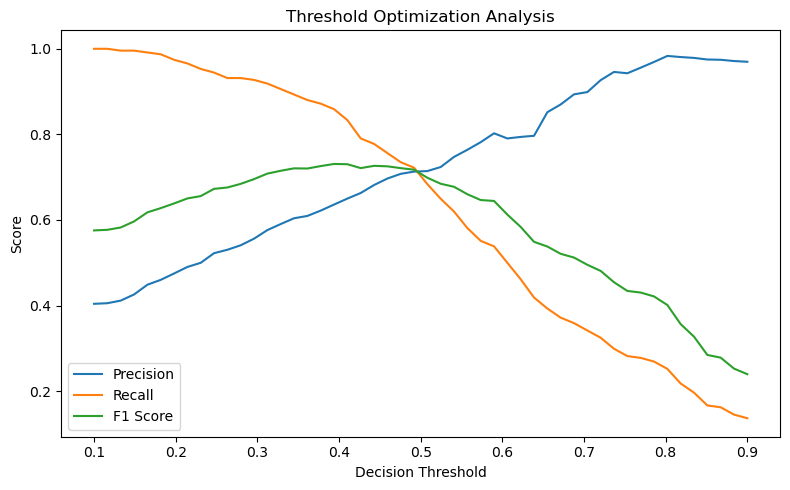

In [26]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.linspace(0.1, 0.9, 50)

precisions = []
recalls = []
f1_scores = []

for t in thresholds:
    y_temp = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_test, y_temp))
    recalls.append(recall_score(y_test, y_temp))
    f1_scores.append(f1_score(y_test, y_temp))

plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1_scores, label="F1 Score")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization Analysis")
plt.legend()
plt.tight_layout()
plt.savefig("threshold_optimization_curve.png", dpi=300)
plt.show()


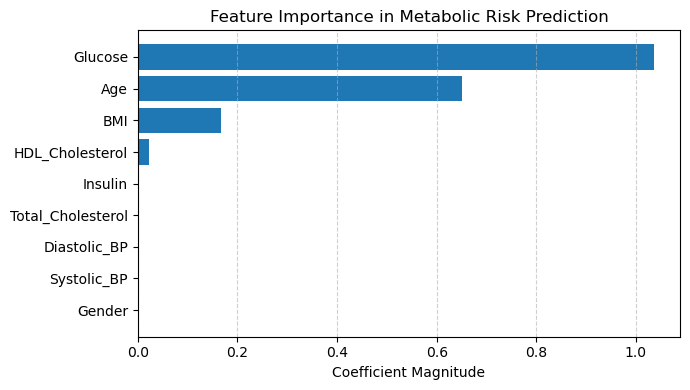

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract coefficients
coefficients = best_log_model.coef_[0]

# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": abs(coefficients)
})

# Sort values
feature_importance = feature_importance.sort_values("Coefficient")

# Plot
plt.figure(figsize=(7,4))
plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.barh(feature_importance["Feature"], feature_importance["Coefficient"])

plt.xlabel("Coefficient Magnitude")
plt.title("Feature Importance in Metabolic Risk Prediction")

plt.tight_layout()

# Save high resolution image for paper
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()